


Epoch 1/5

73666/73666 [==============================] - 168s 2ms/step - loss: 0.0132 - val_loss: 6.4047e-05
Epoch 2/5
73666/73666 [==============================] - 169s 2ms/step - loss: 8.8947e-04 - val_loss: 1.4637e-05
Epoch 3/5
73666/73666 [==============================] - 155s 2ms/step - loss: 6.2761e-04 - val_loss: 1.6162e-05
Epoch 4/5
73666/73666 [==============================] - 154s 2ms/step - loss: 6.2452e-04 - val_loss: 1.4853e-05
Epoch 5/5
73666/73666 [==============================] - 158s 2ms/step - loss: 4.4602e-04 - val_loss: 1.9120e-05


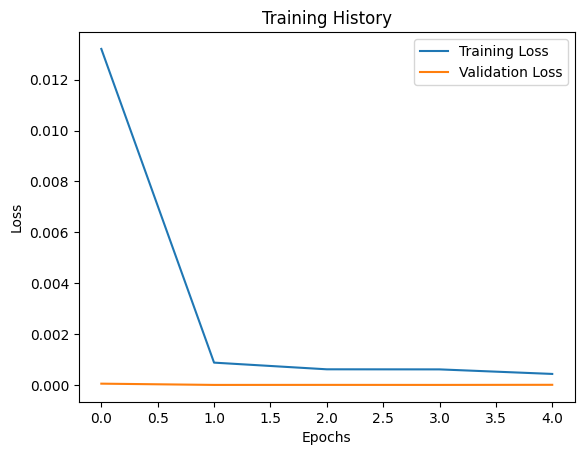

92082/92082 [==============================] - 118s 1ms/step


C:\Users\USER\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


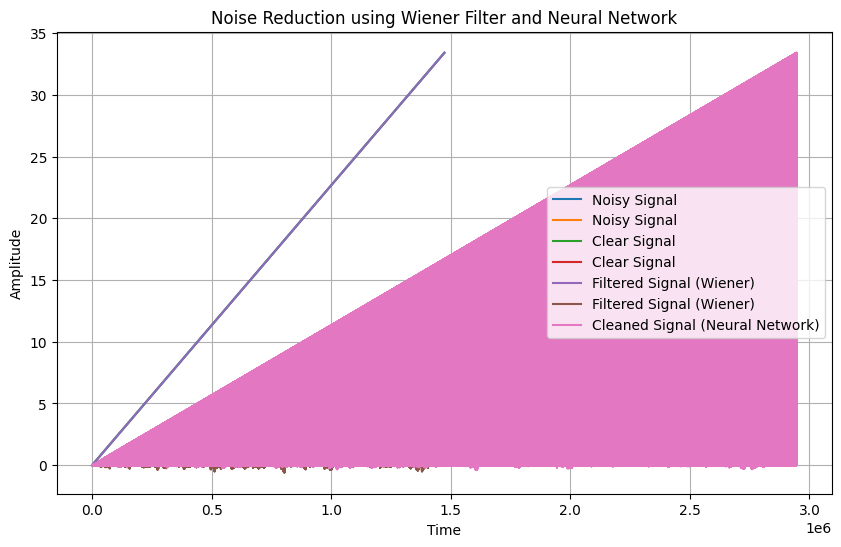

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.io import wavfile

def wiener_filter(input_signal, desired_signal, filter_order):
    """
    Implements the Wiener filter for noise reduction.

    Parameters:
    input_signal (array): The input signal contaminated with noise.
    desired_signal (array): The desired signal (noise-free signal).
    filter_order (int): The order of the Wiener filter.

    Returns:
    filtered_signal (array): The noise-reduced signal.
    """

    # Compute power spectral densities
    P_signal = np.abs(np.fft.fft(desired_signal)) ** 2
    P_noise = np.abs(np.fft.fft(input_signal - desired_signal)) ** 2

    # Compute Wiener filter transfer function
    H = np.conj(P_signal) / (np.conj(P_signal) + P_noise)

    # Apply Wiener filter in frequency domain
    F_input_signal = np.fft.fft(input_signal)
    F_filtered_signal = H * F_input_signal

    # Convert back to time domain
    filtered_signal = np.real(np.fft.ifft(F_filtered_signal))

    return filtered_signal

def load_dat_file(file_path,length=None):
    """
    Load data from a .dat file.

    Parameters:
    file_path (str): The path to the .dat file.

    Returns:
    data (array): The data loaded from the file.
    """
    data =  np.loadtxt(file_path, skiprows=1)
    if length is not None:
        return data[:length]
    else:
        return data


# Load your .dat files
noisy_signal_dat = load_dat_file("fan.dat")
clear_signal_dat = load_dat_file("song.dat",len(noisy_signal_dat))

# Combine clear and noisy signals
input_signal_dat = clear_signal_dat + noisy_signal_dat

# Apply Wiener filter to reduce noise
filter_order = 10
filtered_signal_wiener = wiener_filter(input_signal_dat, clear_signal_dat, filter_order)

# Generate data
noisy_signal = filtered_signal_wiener  # Input to neural network is the Wiener filtered signal

# Create training data
X = noisy_signal.reshape(-1, 1)
y = clear_signal_dat.reshape(-1, 1)  # Using clear_signal as clean signal

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Define neural network model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(1,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Compile model
model.compile(optimizer='adam', loss='mse')

# Train model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=1, batch_size=32)

# Save clear signal data to a .wav file
wavfile.write('audio.wav', 44100, clear_signal_dat)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training History')
plt.legend()
plt.show()

# Perform noise reduction on test data
cleaned_signal_neural_network = model.predict(X)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(noisy_signal_dat, label='Noisy Signal')
plt.plot(clear_signal_dat, label='Clear Signal')
plt.plot(filtered_signal_wiener, label='Filtered Signal (Wiener)')
plt.plot(cleaned_signal_neural_network, label='Cleaned Signal (Neural Network)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Noise Reduction using Wiener Filter and Neural Network')
plt.legend()
plt.grid(True)
plt.show()


73666/73666 [==============================] - 332s 4ms/step - loss: 0.0267 - val_loss: 1.5533e-05


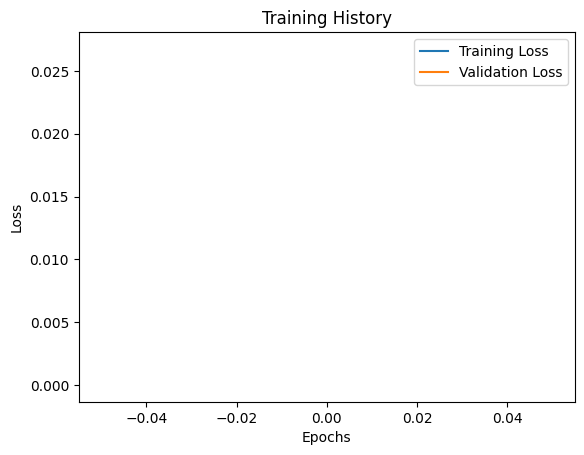

92082/92082 [==============================] - 193s 2ms/step


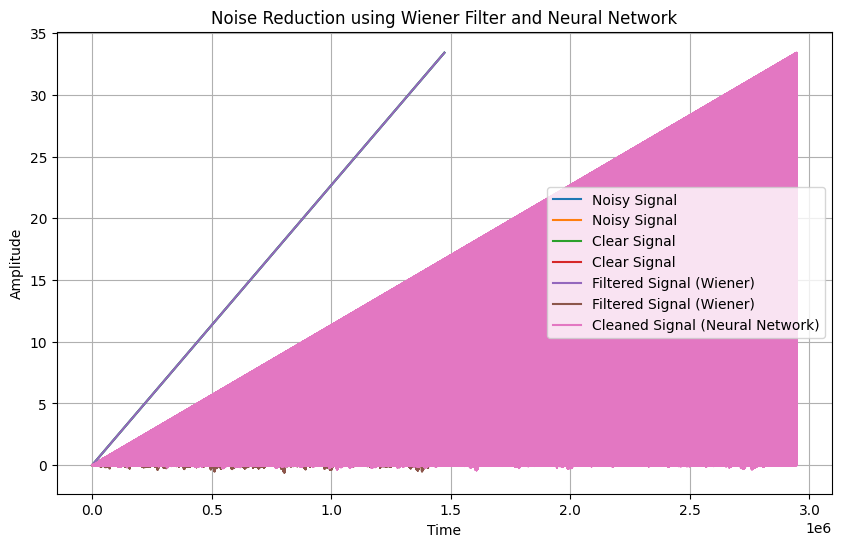

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.io import wavfile

def wiener_filter(input_signal, desired_signal, filter_order):
    """
    Implements the Wiener filter for noise reduction.

    Parameters:
    input_signal (array): The input signal contaminated with noise.
    desired_signal (array): The desired signal (noise-free signal).
    filter_order (int): The order of the Wiener filter.

    Returns:
    filtered_signal (array): The noise-reduced signal.
    """

    # Compute power spectral densities
    P_signal = np.abs(np.fft.fft(desired_signal)) ** 2
    P_noise = np.abs(np.fft.fft(input_signal - desired_signal)) ** 2

    # Compute Wiener filter transfer function
    H = np.conj(P_signal) / (np.conj(P_signal) + P_noise)

    # Apply Wiener filter in frequency domain
    F_input_signal = np.fft.fft(input_signal)
    F_filtered_signal = H * F_input_signal

    # Convert back to time domain
    filtered_signal = np.real(np.fft.ifft(F_filtered_signal))

    return filtered_signal

def load_dat_file(file_path,length=None):
    """
    Load data from a .dat file.

    Parameters:
    file_path (str): The path to the .dat file.

    Returns:
    data (array): The data loaded from the file.
    """
    data =  np.loadtxt(file_path, skiprows=1)
    if length is not None:
        return data[:length]
    else:
        return data


# Load your .dat files
noisy_signal_dat = load_dat_file("fan.dat")
clear_signal_dat = load_dat_file("song.dat",len(noisy_signal_dat))

# Combine clear and noisy signals
input_signal_dat = clear_signal_dat + noisy_signal_dat

# Apply Wiener filter to reduce noise
filter_order = 10
filtered_signal_wiener = wiener_filter(input_signal_dat, clear_signal_dat, filter_order)

# Generate data
noisy_signal = filtered_signal_wiener  # Input to neural network is the Wiener filtered signal

# Create training data
X = noisy_signal.reshape(-1, 1)
y = clear_signal_dat.reshape(-1, 1)  # Using clear_signal as clean signal

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Define neural network model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(1,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Compile model
model.compile(optimizer='adam', loss='mse')

# Train model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=1, batch_size=32)

# Save clear signal data to a .wav file
wavfile.write('audio.wav', 44100, clear_signal_dat)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training History')
plt.legend()
plt.show()

# Perform noise reduction on test data
cleaned_signal_neural_network = model.predict(X)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(noisy_signal_dat, label='Noisy Signal')
plt.plot(clear_signal_dat, label='Clear Signal')
plt.plot(filtered_signal_wiener, label='Filtered Signal (Wiener)')
plt.plot(cleaned_signal_neural_network, label='Cleaned Signal (Neural Network)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Noise Reduction using Wiener Filter and Neural Network')
plt.legend()
plt.grid(True)
plt.show()
